# Imports

In [5]:
# Main Packages
import pandas as pd
import numpy as np

# Graphing
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Low Pass Filter
from scipy.signal import savgol_filter

# Moving Average Filter
from scipy.ndimage import uniform_filter1d

# Filter Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Kalman Filter
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import predict, update, KalmanFilter

# Disable Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Import and Cleaning

In [6]:
Study_no = "MR23-002"
Reactor_num = 711

df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{Study_no} Offline Data")
df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{Study_no} DCS Data")
all_batches = ["MR23-008-710","MR23-008-711","MR23-008-712","MR23-002-710","MR23-002-711","MR23-002-717","MR23-002-718"]
test_batches = ["MR23-008-711","MR23-002-711"]

df_wuxi_offline_MR.head()

,Datetime,Day,VCC-710,VCC-711,VCC-717,VCC-718,VCC-720,Gluc-710,Gluc-711,Gluc-717,Gluc-718,Gluc-720,comments
0,2023-01-26 11:24:51,0.000000,0.401,0.482,0.45,0.474,0.369,5.37,5.37,5.33,5.38,5.33,NaN
1,2023-01-27 11:23:42,0.999201,1.090,1.230,1.10,1.140,0.998,4.72,4.72,4.83,4.75,4.87,NaN
2,2023-01-28 08:56:36,1.897049,2.480,2.750,2.25,2.580,2.240,4.20,4.27,4.21,4.05,4.22,NaN
3,2023-01-29 08:04:30,2.860868,6.070,6.110,5.11,5.670,5.060,3.04,3.14,3.05,2.92,3.09,NaN
4,2023-01-30 12:08:33,4.030347,12.200,14.800,19.70,11.900,12.400,3.53,3.56,3.20,3.06,3.33,NaN


# State Estimator 1: Kalman Filter

### Kalman Filter Parameters and Model

In [7]:
feed_conc = 80
gluc_conc = 468
growth_rate = np.array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])

def a1(t1, t2, growth_rate):
    return np.exp((t1-t2)*np.polyval(growth_rate,t2))

def a2(t1, t2, growth_rate, glcCSR):
    return np.polyval(glcCSR, t1)*(t1-t2)*a1(t1,t2,growth_rate)

def b1(volume):
    return feed_conc/volume

def b2(volume):
    return gluc_conc/volume

### Optimization

In [8]:
class Optimizer:

    def __init__(self, initial_array, weight, metric = 1):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.metric = metric

    def objective_func(self, input):
        rmse_sum = []
        smoothness_sum = []
        for batch in test_batches:
            df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} DCS Data")
            df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} Offline Data")
            offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{batch[9:]}"].drop(index=12))
            offline_time = df_wuxi_offline_MR["Day"].drop(index=12)
            
            initial = np.array([0.55, np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])[0]])
            kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
            kf.x = initial
            kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=abs(input[0]))
            kf.H = np.array([[0,1]])
            kf.P = np.diag([100., 16.])
            kf.R = np.array([[abs(input[1])]])

            u=np.array(df_wuxi_online[[f"{batch[9:]}-FeedA-Daily",f"{batch[9:]}-Glucose-Daily"]])
            zs=np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])

            volume=[1800]
            model_x = []
            xs = []
            cov = []
            k_gain = []

            time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs))

            for count, value in enumerate(df_wuxi_online["Day"]):
                if count != 0:
                    kf.F = np.array([[a1(value, df_wuxi_online["Day"][count-1], growth_rate), 0],
                                    [a2(value, df_wuxi_online["Day"][count-1], growth_rate, glcCSR), 1]]) # type: ignore
                    kf.B = np.array([[0, 0],
                                    [b1(volume[count-1]), b2(volume[count-1])]])
                    new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
                    volume.append(new_vol)
                kf.predict(u[count-1])
                # restructure u matrix to have different time windows
                # create my own frequency so not limited by raman time intervals
                model_x.append(kf.x)
                # if count % 10 == 0:
                kf.update(zs[count])
                xs.append(kf.x)
                cov.append(kf.P)
                k_gain.append(kf.K)

            offline_kalman = np.interp(offline_time,df_wuxi_online["Day"],np.array(xs)[:,1])
            rmse = np.sqrt((offline_val-offline_kalman).sum()**2)
            rmse = mean_squared_error(offline_val, offline_kalman, squared=False)
            kf_diff = np.diff(np.array(xs)[:,1])
            smoothness = np.std(kf_diff[kf_diff<1])
            rmse_sum.append(rmse)
            smoothness_sum.append(smoothness)

        if self.metric:
            metric = (self.weight*np.sum(rmse_sum) + (1-self.weight)*np.sum(smoothness_sum))**2
        else:
            metric = (rmse)**2
        if self.iterations % 1000 == 0:
            print("Current Error: ",metric)
        return metric
    
    def objective_func_2(self, input):
        # input = np.clip(input, 0, None)
        offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{batch[9:]}"].drop(index=12))
        offline_time = df_wuxi_offline_MR["Day"].drop(index=12)
        kf.x = initial
        kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=input[0])
        kf.H = np.array([[0,1]])
        kf.P = np.diag([100., 16.])
        kf.R = np.array([[input[1]]])
        xs = []
        for count, value in enumerate(time):
            xs.append(kf.x)
            kf.predict(u[count-1])
            if count != 0:
                if count % int(input[2]) == 0 and value > input[3]:
                    kf.update(zs[count])
                kf.F = np.array([[a1(value, time[count-1], growth_rate), 0],
                                [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
                kf.B = np.array([[0, 0],
                                [b1(volume[count-1]), b2(volume[count-1])]])
                new_x = np.dot(kf.F, kf.x) + np.dot(kf.B, u[count-1])
                model_x.append(new_x)
        offline_kalman = np.interp(offline_time,time,np.array(xs)[:,1])
        rmse = np.sqrt((offline_val-offline_kalman).sum()**2)
        rmse = mean_squared_error(offline_val, offline_kalman, squared=False)
        kf_diff = np.diff(np.array(xs)[:,1])
        smoothness = np.std(kf_diff[kf_diff<1])
        metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
        return metric
    
    def optimize(self, obj_func):
        constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
        if obj_func == 1:
            res = minimize(
                self.objective_func, 
                self.initial_array, 
                method="SLSQP", 
                constraints=constraints,
                options={'disp': True}
            )
        else:
            res = minimize(
                self.objective_func_2, 
                self.initial_array, 
                method="SLSQP", 
                constraints=constraints,
            )
        return res.x
    
    def minzero_constraint(self, input):
        if (input[0] or input[1] or input[2]) < 0:
            indicator = -1
        else:
            indicator = 1
        return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
initial_array = [0,100]
kf_optimize = Optimizer(initial_array, weight=0.5,metric=1)
kf_result = kf_optimize.optimize(obj_func=1)
print(kf_result)

Current Error:  1.262712199346152
Current Error:  1.2627055623574865
Current Error:  1.262712199348776
Current Error:  0.5261801768224935
Current Error:  0.5311091698622211
Current Error:  0.5446573500758353
Current Error:  0.5176456736096746
Current Error:  0.4981836962493306
Current Error:  0.476348332296562
Current Error:  0.46174596142158325
Current Error:  0.45240164781633724
Current Error:  0.4421036814406784
Current Error:  0.43907244242627386
Current Error:  0.4330351228298047
Current Error:  0.43303512274960176
Current Error:  0.43303512283103196
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4330351228298047
            Iterations: 2
            Function evaluations: 16
            Gradient evaluations: 2
[ 0.43679549 99.99999983]


### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Kalman Filter: R711')

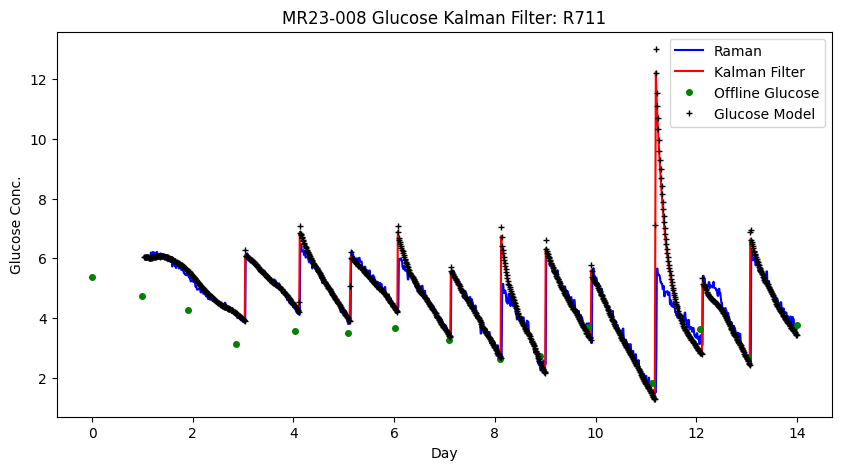

In [9]:
initial = np.array([0.55, np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])[0]])
kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
kf.x = initial
kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=abs(kf_result[0]))
kf.H = np.array([[0,1]])
kf.P = np.diag([100., 16.])
kf.R = np.array([[abs(kf_result[1])]])

u=np.array(df_wuxi_online[[f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]])
zs=np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

# np.array(df_wuxi_online[["Datetime",f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]].set_index("Datetime").resample("6H").sum())
# np.array(df_wuxi_online[["Datetime",f"{Reactor_num}-Raman-Glucose"]].set_index("Datetime").resample("6H").first())
# np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

volume=[1800]
model_x = []
xs = []
cov = []
k_gain = []

time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs))

for count, value in enumerate(df_wuxi_online["Day"]):
    if count != 0:
        kf.F = np.array([[a1(value, df_wuxi_online["Day"][count-1], growth_rate), 0],
                        [a2(value, df_wuxi_online["Day"][count-1], growth_rate, glcCSR), 1]]) # type: ignore
        kf.B = np.array([[0, 0],
                        [b1(volume[count-1]), b2(volume[count-1])]])
        new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
        volume.append(new_vol)
    kf.predict(u[count-1])
    # restructure u matrix to have different time windows
    # create my own frequency so not limited by raman time intervals

    # try resetting to offline values everytime they become available and see how much accuracy improves
    model_x.append(kf.x)
    # if count % 10 == 0:
    kf.update(zs[count])
    xs.append(kf.x)
    cov.append(kf.P)
    k_gain.append(kf.K)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],zs,"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],np.array(xs)[:,1], "r-",label="Kalman Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")
plt.plot(df_wuxi_online["Day"],np.array(model_x)[:,1],"k+", markersize=4, label="Glucose Model")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Kalman Filter: R{Reactor_num}")

# check the starting raman values to ensure they are after the raman batch was started

### Observer Metrics

In [10]:
raman_data = zs
kf_data = np.array(xs)[:,1]
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
kalman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],kf_data),12)
kalman_diff = np.diff(np.array(xs)[:,1])
raman_diff = np.diff(zs[1:])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

kf_mape = round(mean_absolute_percentage_error(offline_val,kalman_offline)*100,2)
kf_rmse = round(mean_squared_error(offline_val, kalman_offline, squared=False),2)
kf_smooth = round(np.std(kalman_diff[kalman_diff<1.5]),2)

print("Kalman MAPE: ", kf_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Kalman RMSE: ", kf_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Kalman Smoothnes: ", kf_smooth)
print("Raman Smoothness: ", raman_smooth)

Kalman MAPE:  15.35
Raman MAPE:  14.23
-------------------------
Kalman RMSE:  0.69
Raman RMSE:  0.67
-------------------------
Kalman Smoothnes:  0.06
Raman Smoothness:  0.11


# State Estimator 2: Alpha Beta Filter

### Optimization

In [11]:
class AlphaBetaFilter:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        self.filtered_value = None
        self.filtered_velocity = None

    def update(self, measurement):
        if self.filtered_value is None:
            self.filtered_value = measurement
            return self.filtered_value

        if self.filtered_velocity is None:
            self.filtered_velocity = 0.0

        residual = measurement - self.filtered_value
        self.filtered_value += self.alpha * residual
        self.filtered_velocity += self.beta * residual

        return self.filtered_value

class Optimizer:

    def __init__(self, initial_array, weight, metric = 1):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.metric = metric

    def objective_func(self, input):
        rmse_sum = []
        smoothness_sum = []
        for batch in test_batches:
            df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} DCS Data")
            df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} Offline Data")
            offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{batch[9:]}"].drop(index=12))
            offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

            filter = AlphaBetaFilter(alpha=input[0], beta=input[1])
            measurements = np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])
            filtered_values = []

            for measurement in measurements:
                filtered_value = filter.update(measurement)
                filtered_values.append(filtered_value)

            offline_ab = np.interp(offline_time,df_wuxi_online["Day"],filtered_values)
            rmse = np.sqrt((offline_val-offline_ab).sum()**2)
            rmse = mean_squared_error(offline_val, offline_ab, squared=False)
            ab_diff = np.diff(filtered_values)
            smoothness = np.std(ab_diff[ab_diff<1])
            rmse_sum.append(rmse)
            smoothness_sum.append(smoothness)

        if self.metric:
            metric = (self.weight*np.sum(rmse_sum) + (1-self.weight)*np.sum(smoothness_sum))**2
        else:
            metric = (np.sum(rmse_sum))**2
        if self.iterations % 1000 == 0:
            print("Current Error: ",metric)
        return metric

    def optimize(self):
        constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
        res = minimize(
            self.objective_func, 
            self.initial_array, 
            # method="SLSQP", 
            constraints=constraints,
            bounds=(
                (0,2),
                (0,2),
            ),
            options={'disp': True}
        )
        return res.x
    
    def minzero_constraint(self, input):
        if (input[0] or input[1] or input[2]) < 0:
            indicator = -1
        else:
            indicator = 1
        return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
initial_array = [0.5,0.5]
kf_optimize = Optimizer(initial_array, weight=0.5,metric=1)
ab_result = kf_optimize.optimize()
print(ab_result)

# Cross validation for improving hyperparameters?

Current Error:  0.5121332754235728
Current Error:  0.5121332761955477
Current Error:  0.5121332754235728
Current Error:  0.5226137535123387
Current Error:  0.5118592597159114
Current Error:  0.5118592604903343
Current Error:  0.5118592597159114
Current Error:  0.5217166067678044
Current Error:  0.5345330614201282
Current Error:  0.5114679470967153
Current Error:  0.5114679478751406
Current Error:  0.5114679470967153
Current Error:  8.174846996575663
Current Error:  0.5349279395644025
Current Error:  0.5112129644417188
Current Error:  0.5112129652230502
Current Error:  0.5112129644417188
Current Error:  8.174846996575663
Current Error:  0.5342495578979758
Current Error:  0.513967675855032
Current Error:  0.5142477156571381
Current Error:  0.511210435298276
Current Error:  0.5112104360796373
Current Error:  0.511210435298276
Current Error:  8.174846996500216
Current Error:  0.5342428504214158
Current Error:  0.5139645933352416
Current Error:  0.5142446091770514
Current Error:  0.51120790

### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Alpha-Beta Filter: R711')

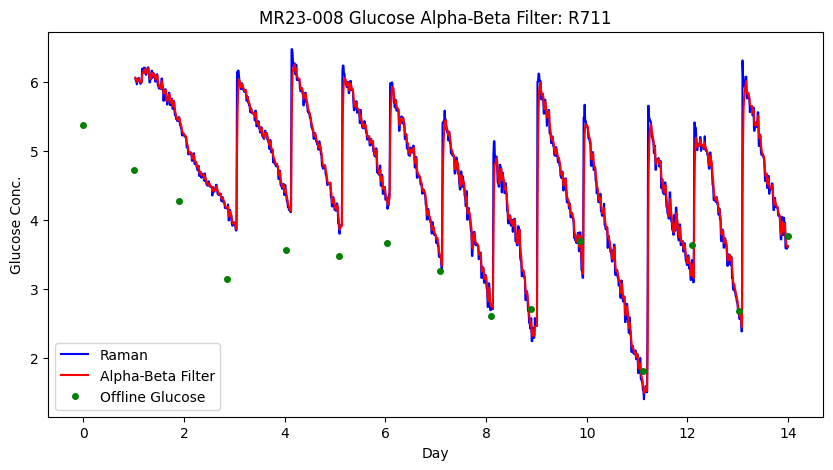

In [12]:
class AlphaBetaFilter:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        self.filtered_value = None
        self.filtered_velocity = None

    def update(self, measurement):
        if self.filtered_value is None:
            self.filtered_value = measurement
            return self.filtered_value

        if self.filtered_velocity is None:
            self.filtered_velocity = 0.0

        residual = measurement - self.filtered_value
        self.filtered_value += self.alpha * residual
        self.filtered_velocity += self.beta * residual

        return self.filtered_value

# Example usage
filter = AlphaBetaFilter(alpha=ab_result[0], beta=ab_result[1])

measurements = np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])
filtered_values = []

for measurement in measurements:
    filtered_value = filter.update(measurement)
    filtered_values.append(filtered_value)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],measurements,"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],filtered_values, "r-",label="Alpha-Beta Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Alpha-Beta Filter: R{Reactor_num}")

### Observer Metrics

In [13]:
raman_data = measurements
ab_data = filtered_values
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
ab_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],ab_data),12)
ab_diff = np.diff(filtered_values)
raman_diff = np.diff(measurements)

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

ab_mape = round(mean_absolute_percentage_error(offline_val,ab_offline)*100,2)
ab_rmse = round(mean_squared_error(offline_val, ab_offline, squared=False),2)
ab_smooth = round(np.std(ab_diff[ab_diff<1.5]),2)

print("Alpha-Beta MAPE: ", ab_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Alpha-Beta RMSE: ", ab_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Alpha-Beta Smoothnes: ", ab_smooth)
print("Raman Smoothness: ", raman_smooth)

Alpha-Beta MAPE:  13.94
Raman MAPE:  14.23
-------------------------
Alpha-Beta RMSE:  0.67
Raman RMSE:  0.67
-------------------------
Alpha-Beta Smoothnes:  0.12
Raman Smoothness:  0.11


# State Estimator 3: Luenberger Observer (Unfinished)

### Main Script

In [14]:
# u=np.array(df_wuxi_online[[f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]])
# zs=np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

# def luenberger_observer(A, B, C, Q, R):
#   """
#   Implements a Luenberger observer for a system with one measurement.

#   Args:
#     A: The system matrix.
#     B: The input matrix.
#     C: The measurement matrix.
#     Q: The state covariance matrix.
#     R: The measurement covariance matrix.

#   Returns:
#     The observer gain matrix.
#   """

#   # Calculate the observer gain matrix.
#   L = np.linalg.inv(C.T @ np.linalg.inv(R) @ C + A.T @ np.linalg.inv(Q) @ A) @ A.T @ np.linalg.inv(Q) @ C

#   return L

# def main():
#   volume = [1800]
#   # Define the system parameters.
#   C = np.array([[1, 0]])
#   Q = Q_discrete_white_noise(dim=2, dt=1, var=1)
#   R = np.array([[1]])

#   # Calculate the observer gain matrix.

#   # Simulate the system and the observer.
#   x = np.array([0, 0])
#   y = np.array([0])

#   for count, i in enumerate(df_wuxi_online["Day"]):

#     A = np.array([[a1(value, time[count-1], growth_rate), 0],
#                   [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
#     B = np.array([[0, 0],
#                   [b1(volume[count-1]), b2(volume[count-1])]])
#     new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
#     volume.append((new_vol))
#     L = luenberger_observer(A, B, C, Q, R)

#     x = A @ x + B @ u
#     y = C @ x + np.random.randn()
#     z = C @ x + L @ (y - C @ x)
#     print(x, z)

# if __name__ == "__main__":
#   main()


# State Estimator 4: Moving Average Estimator

### Optimize

In [15]:
class Optimizer:

    def __init__(self, weight):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.optimal_rmse = 100
        self.N = 0

    def objective_func(self):
        for n in range(1,100):
            offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
            offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

            N = n
            x = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
            y = uniform_filter1d(x, size=N)

            offline_mae = np.interp(offline_time,df_wuxi_online["Day"], y)
            rmse = mean_squared_error(offline_val, offline_mae, squared=False)
            mae_diff = np.diff(y)
            smoothness = np.std(mae_diff[mae_diff<1])
            metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
            if metric < self.optimal_rmse:
                self.optimal_rmse = metric
                self.N = n
            print(metric)

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
kf_optimize = Optimizer(weight=0.5)
result = kf_optimize.objective_func()
print(kf_optimize.N)

# Cross validation for improving hyperparameters?

0.1487978400906467
0.13837586222532297
0.1523004850636047
0.15541085349061254
0.1489297695503073
0.14620708873304825
0.1394866350520537
0.13811577688476284
0.13699186487293896
0.13708180628854502
0.14053877100078027
0.13943249508565222
0.14815966704386982
0.14647855389538686
0.15901040631851945
0.157835611818419
0.17024517360768301
0.16884649840966195
0.18098027347392512
0.179216423260466
0.19432749961518578
0.1918381107093604
0.20682097488754528
0.20486377033621594
0.21945680769827466
0.21707559405688234
0.23208013501684374
0.2300844570604871
0.24436726883289145
0.24242852420753144
0.2558943052183668
0.25358640011338757
0.26688762850675635
0.26469566099535535
0.27765000283286684
0.27559141183889946
0.28907878538658544
0.2873017582332565
0.30072657341077447
0.29918247863854114
0.3113253409701845
0.3092674821798175
0.3210268442640332
0.3187884342810282
0.33002776225649194
0.3282200921591099
0.3386301577076213
0.33691865596659515
0.3464165788451215
0.34523086398631864
0.3541345207493876


### Main Script

[6.01990967 6.01990967 6.02899723 ... 3.67001243 3.63309362 3.59617481]


Text(0.5, 1.0, 'MR23-008 Glucose Alpha-Beta Filter: R711')

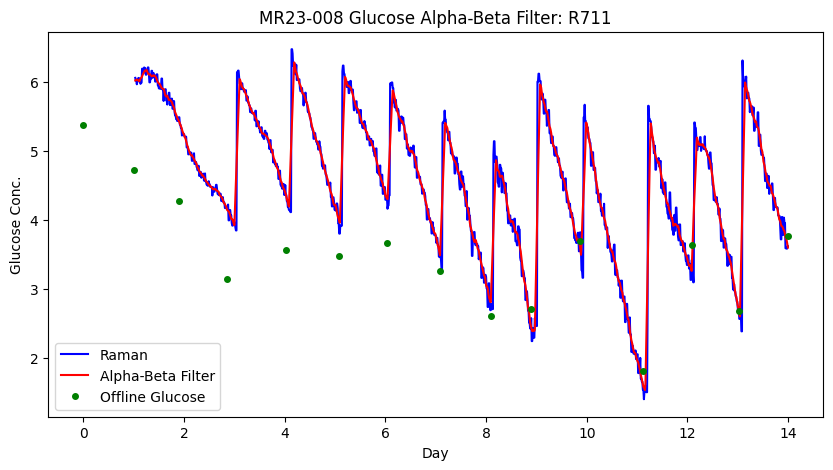

In [16]:
N = 10
x = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
y = uniform_filter1d(x, size=N)
print(y)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],df_wuxi_online[f"{Reactor_num}-Raman-Glucose"],"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],y, "r-",label="Alpha-Beta Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Alpha-Beta Filter: R{Reactor_num}")

### Observer Metrics

In [17]:
raman_data = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
mae_data = y
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
mae_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],mae_data),12)
mae_diff = np.diff(y)
raman_diff = np.diff(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

mae_mape = round(mean_absolute_percentage_error(offline_val,mae_offline)*100,2)
mae_rmse = round(mean_squared_error(offline_val, mae_offline, squared=False),2)
mae_smooth = round(np.std(mae_diff[mae_diff<1.5]),2)

print("MAE MAPE: ", mae_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("MAE RMSE: ", mae_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("MAE Smoothnes: ", mae_smooth)
print("Raman Smoothness: ", raman_smooth)

MAE MAPE:  14.42
Raman MAPE:  14.23
-------------------------
MAE RMSE:  0.66
Raman RMSE:  0.67
-------------------------
MAE Smoothnes:  0.08
Raman Smoothness:  0.11


# State Estimator 5: Savgol Filter

### Optimization

In [18]:
class Optimizer:

    def __init__(self, weight):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.optimal_rmse = 100
        self.window_len = 0
        self.polyorder = 0

    def objective_func(self):
        for polyorder in range(1,4):
            for window_len in range(5,40):
                offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
                offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

                filtered_data = savgol_filter(x=df_wuxi_online[f"{Reactor_num}-Raman-Glucose"], window_length=window_len, polyorder=polyorder)

                offline_savgol = np.interp(offline_time,df_wuxi_online["Day"], filtered_data)
                rmse = mean_squared_error(offline_val, offline_savgol, squared=False)
                savgol_diff = np.diff(filtered_data)
                smoothness = np.std(savgol_diff[savgol_diff<1])
                metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
                if metric < self.optimal_rmse:
                    self.optimal_rmse = metric
                    self.window_len = window_len
                    self.polyorder = polyorder
                print(metric)

    # def optimize(self):
    #     constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
    #     res = minimize(
    #         self.objective_func, 
    #         self.initial_array, 
    #         method="SLSQP", 
    #         constraints=constraints,
    #         options={'disp': True}
    #     )
    #     return res.x
    
    # def minzero_constraint(self, input):
    #     if (input[0] or input[1] or input[2]) < 0:
    #         indicator = -1
    #     else:
    #         indicator = 1
    #     return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
kf_optimize = Optimizer( weight=0.5)
result = kf_optimize.objective_func()
print(kf_optimize.window_len, kf_optimize.polyorder)

# Cross validation for improving hyperparameters?

0.149250965107531
0.14151579137820522
0.1399378679532317
0.1384251490286115
0.13858223746776535
0.14230793790956392
0.14208103008197512
0.15164052836666395
0.1498409714438348
0.1613584639023287
0.1570443518341785
0.17025300532418267
0.16786984991746162
0.18052284357848378
0.17796586040533077
0.19394820356945486
0.19190749927707898
0.20821355213257067
0.20513949302757378
0.22051076710205497
0.21788398284918523
0.23304590251350416
0.2305601872623699
0.24590145603217456
0.24365974951736058
0.2579450940703346
0.2556224391799086
0.26921473926487294
0.26615476153916157
0.2795628957439179
0.276810244967444
0.29050702981973
0.2878428657420239
0.3016195133787868
0.29968902179415274
0.15534271631626562
0.16004550243894924
0.15543808257992128
0.15063608366563766
0.15523495637555515
0.14855524160512565
0.14743728534922387
0.14244572854593124
0.1418491381825361
0.1423868339677533
0.14268235780962418
0.1433431631756622
0.14053645406300722
0.1436634746604037
0.14060495084102054
0.14284221063309394
0.

### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Savgol Filter: R711')

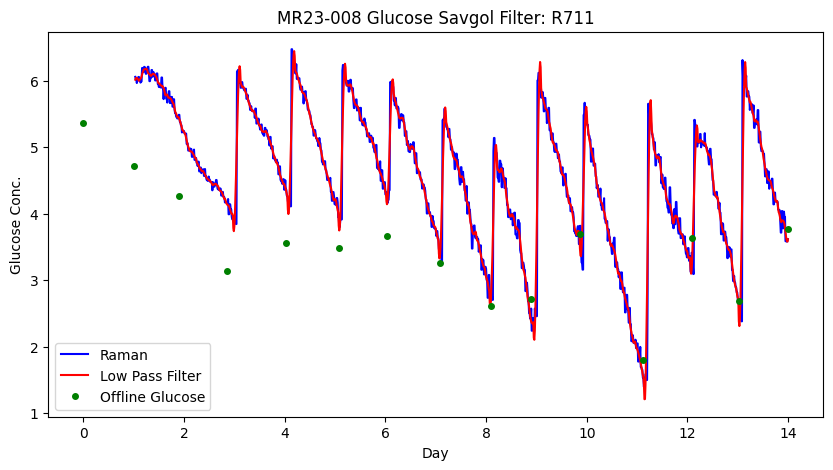

In [19]:
# Filter the data.
filtered_data = savgol_filter(x=df_wuxi_online[f"{Reactor_num}-Raman-Glucose"], window_length=kf_optimize.window_len, polyorder=kf_optimize.polyorder)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],df_wuxi_online[f"{Reactor_num}-Raman-Glucose"],"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],filtered_data, "r-",label="Low Pass Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Savgol Filter: R{Reactor_num}")

### Observer Metrics

In [20]:
raman_data = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
savgol_data = filtered_data
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
savgol_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],savgol_data),12)
savgol_diff = np.diff(filtered_data)
raman_diff = np.diff(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

savgol_mape = round(mean_absolute_percentage_error(offline_val,savgol_offline)*100,2)
savgol_rmse = round(mean_squared_error(offline_val, savgol_offline, squared=False),2)
savgol_smooth = round(np.std(savgol_diff[savgol_diff<1.5]),2)

print("Savgol MAPE: ", savgol_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Savgol RMSE: ", savgol_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Savgol Smoothnes: ", savgol_smooth)
print("Raman Smoothness: ", raman_smooth)

Savgol MAPE:  14.06
Raman MAPE:  14.23
-------------------------
Savgol RMSE:  0.64
Raman RMSE:  0.67
-------------------------
Savgol Smoothnes:  0.1
Raman Smoothness:  0.11


# Result Summary

### One Batch Summary

(0.0, 1.0, 0.0, 1.0)

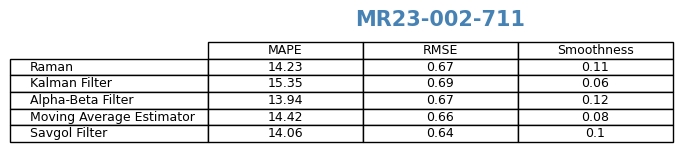

In [21]:
df_summary = pd.DataFrame(
    index=["Raman", "Kalman Filter", "Alpha-Beta Filter", "Moving Average Estimator", "Savgol Filter"],
    columns=["MAPE","RMSE", "Smoothness"],
    data=[[raman_mape, raman_rmse, raman_smooth],[kf_mape, kf_rmse, kf_smooth],[ab_mape, ab_rmse, ab_smooth],[mae_mape, mae_rmse, mae_smooth],[savgol_mape, savgol_rmse, savgol_smooth]]
)
df_summary.index.name = "Metric"
df_summary

#initialize figure
plt.rcParams["figure.autolayout"] = True
fig = plt.figure(figsize = (6, .1))
ax = fig.add_subplot(111)

#create table
table = ax.table(cellText = df_summary.values, rowLabels = df_summary.index, 
         colLabels = df_summary.columns, cellLoc='center', fontsize=25)

#add title to table
ax.set_title(f'{Study_no}-{Reactor_num}',
fontdict={'fontsize': 15,
                        'fontweight': 'bold',
                        'color': 'steelblue'},)
table.auto_set_font_size(False)
table.set_fontsize(9)
#turn axes off
ax.axis('off')


### All Batch Summary

#### Kalman Filter

In [22]:
feed_conc = 80
gluc_conc = 468
growth_rate = np.array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])

def a1(t1, t2, growth_rate):
    return np.exp((t1-t2)*np.polyval(growth_rate,t2))

def a2(t1, t2, growth_rate, glcCSR):
    return np.polyval(glcCSR, t1)*(t1-t2)*a1(t1,t2,growth_rate)

def b1(volume):
    return feed_conc/volume

def b2(volume):
    return gluc_conc/volume

In [23]:
raman_mape_list = []
raman_rmse_list = []
raman_smooth_list = []

kf_mape_list = []
kf_rmse_list = []
kf_smooth_list = []

for batch in all_batches:
    df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} DCS Data")
    df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} Offline Data")
    initial = np.array([0.55, np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])[0]])
    kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
    kf.x = initial
    kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=abs(kf_result[0]))
    kf.H = np.array([[0,1]])
    kf.P = np.diag([100., 16.])
    kf.R = np.array([[abs(kf_result[1])]])

    u=np.array(df_wuxi_online[[f"{batch[9:]}-FeedA-Daily",f"{batch[9:]}-Glucose-Daily"]])
    zs=np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])

    # np.array(df_wuxi_online[["Datetime",f"{batch[9:]}-FeedA-Daily",f"{batch[9:]}-Glucose-Daily"]].set_index("Datetime").resample("6H").sum())
    # np.array(df_wuxi_online[["Datetime",f"{batch[9:]}-Raman-Glucose"]].set_index("Datetime").resample("6H").first())
    # np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])

    volume=[1800]
    model_x = []
    xs = []
    cov = []
    k_gain = []

    time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs))

    for count, value in enumerate(df_wuxi_online["Day"]):
        if count != 0:
            kf.F = np.array([[a1(value, df_wuxi_online["Day"][count-1], growth_rate), 0],
                            [a2(value, df_wuxi_online["Day"][count-1], growth_rate, glcCSR), 1]]) # type: ignore
            kf.B = np.array([[0, 0],
                            [b1(volume[count-1]), b2(volume[count-1])]])
            new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
            volume.append(new_vol)
        kf.predict(u[count-1])
        # restructure u matrix to have different time windows
        # create my own frequency so not limited by raman time intervals

        # try resetting to offline values everytime they become available and see how much accuracy improves
        model_x.append(kf.x)
        # if count % 10 == 0:
        kf.update(zs[count])
        xs.append(kf.x)
        cov.append(kf.P)
        k_gain.append(kf.K)

    raman_data = zs
    kf_data = np.array(xs)[:,1]
    offline = df_wuxi_offline_MR["Day"]
    offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{batch[9:]}"].drop(index=12))
    raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
    kalman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],kf_data),12)
    kalman_diff = np.diff(np.array(xs)[:,1])
    raman_diff = np.diff(zs[1:])

    raman_mape_list.append(round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2))
    raman_rmse_list.append(round(mean_squared_error(offline_val, raman_offline, squared=False),2))
    raman_smooth_list.append(round(np.std(raman_diff[raman_diff<1.5]),2))

    kf_mape_list.append(round(mean_absolute_percentage_error(offline_val,kalman_offline)*100,2))
    kf_rmse_list.append(round(mean_squared_error(offline_val, kalman_offline, squared=False),2))
    kf_smooth_list.append(round(np.std(kalman_diff[kalman_diff<1.5]),2))

#### Alpha-Beta Filter

In [24]:
class AlphaBetaFilter:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        self.filtered_value = None
        self.filtered_velocity = None

    def update(self, measurement):
        if self.filtered_value is None:
            self.filtered_value = measurement
            return self.filtered_value

        if self.filtered_velocity is None:
            self.filtered_velocity = 0.0

        residual = measurement - self.filtered_value
        self.filtered_value += self.alpha * residual
        self.filtered_velocity += self.beta * residual

        return self.filtered_value

ab_mape_list = []
ab_rmse_list = []
ab_smooth_list = []

for batch in all_batches:
    df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} DCS Data")
    df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{batch[:8]} Offline Data")
    
    filter = AlphaBetaFilter(alpha=ab_result[0], beta=ab_result[1])

    measurements = np.array(df_wuxi_online[f"{batch[9:]}-Raman-Glucose"])
    filtered_values = []

    for measurement in measurements:
        filtered_value = filter.update(measurement)
        filtered_values.append(filtered_value)

    ab_data = filtered_values
    offline = df_wuxi_offline_MR["Day"]
    offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{batch[9:]}"].drop(index=12))
    ab_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],ab_data),12)
    ab_diff = np.diff(filtered_values)

    ab_mape_list.append(round(mean_absolute_percentage_error(offline_val,ab_offline)*100,2))
    ab_rmse_list.append(round(mean_squared_error(offline_val, ab_offline, squared=False),2))
    ab_smooth_list.append(round(np.std(ab_diff[ab_diff<1.5]),2))

#### Results Table

In [25]:
mape_column = []
rmse_column = []
smoothness_column = []
for i in range(len(all_batches)):
    mape_column.extend([raman_mape_list[i],kf_mape_list[i],ab_mape_list[i]])
    rmse_column.extend([raman_rmse_list[i],kf_rmse_list[i],ab_rmse_list[i]])
    smoothness_column.extend([raman_smooth_list[i],kf_smooth_list[i],ab_smooth_list[i]])

In [26]:
batch_index = ["MR23-008-710","MR23-008-711","MR23-008-712","MR23-002-710","MR23-002-711","MR23-002-717","MR23-002-718"]
batch_index = [val for val in batch_index for _ in (0, 1, 2)]
filter_index = ["Raman", "Kalman Filter", "Alpha-Beta Filter"]
filter_index = filter_index*len(all_batches)
tuples = list(zip(*[batch_index,filter_index]))
index = pd.MultiIndex.from_tuples(tuples, names=["Batch", "Filter"])

result_summary = pd.DataFrame(
    index=index,
    columns=["MAPE","RMSE","Smoothness"],
    data=(np.array([mape_column,rmse_column,smoothness_column]).T)
)

#### Final Table

In [27]:
result_summary

MAPE  RMSE  Smoothness
Batch        Filter                                    
MR23-008-710 Raman              12.36  0.53        0.44
             Kalman Filter      12.60  0.53        0.05
             Alpha-Beta Filter  13.80  0.58        0.27
MR23-008-711 Raman              12.16  0.56        0.13
             Kalman Filter      12.10  0.55        0.03
             Alpha-Beta Filter  12.24  0.57        0.12
MR23-008-712 Raman              10.60  0.44        0.12
             Kalman Filter      12.19  0.51        0.03
             Alpha-Beta Filter   9.88  0.43        0.12
MR23-002-710 Raman              21.12  0.69        0.15
             Kalman Filter      18.05  0.68        0.09
             Alpha-Beta Filter  22.05  0.70        0.12
MR23-002-711 Raman              14.23  0.67        0.11
             Kalman Filter      15.35  0.69        0.06
             Alpha-Beta Filter  13.94  0.67        0.12
MR23-002-717 Raman              22.20  0.84        0.15
             Kalman Filter      25.61  0.86        0.06
             Alpha-Beta Filter  24.28  0.85        0.13
MR23-002-718 Raman              15.59  0.70        0.15
             Kalman Filter      18.34  0.78        0.06
             Alpha-Beta Filter  16.18  0.72        0.12

In [28]:
test = ([1,2,3,4,5],[6,7,8,9])
test[0][0]

1

In [31]:
result_summary.sample().iloc[0]

MAPE          18.05
RMSE           0.68
Smoothness     0.09
Name: (MR23-002-710, Kalman Filter), dtype: float64